# 14 - Homeomorphism Decision API Deep Dive

The **Homeomorphism Decision System** is the top-level interface of `pySurgery`. It abstracts away the complex interplay of homology, cup products, intersection forms, and Wall groups into a set of dimension-aware analyzers. These functions ask: "Are these two manifolds homeomorphic?" and provide a structured result containing the verdict, the reasoning, and the underlying certificates.

## Learning Goals
- **Invoke the Decision API**: Use `analyze_homeomorphism_nD` for 2D, 3D, 4D, and high dimensions.
- **Parse Homeomorphism Results**: Understand the `status` (success, impediment, inconclusive) and `reasoning`.
- **Handle Missing Data**: Learn how the API flags what evidence is required to upgrade a verdict.
- **Theorem Tagging**: See how results are linked to specific topological theorems (Classification of Surfaces, Freedman's Theorem, etc.).
- **Visualize Decision Flow**: Plot the branch matrix paths taken during a classification task.

## Formal Grounding

### The Decision Logic
Each dimension has a different classification regime:
- **2D**: Completely determined by Euler characteristic, Orientability, and Boundary components.
- **3D**: Relies on Geometrization (Perelman/Thurston) and Prime Decomposition.
- **4D**: Determined by the Intersection Form and the Kirby-Siebenmann invariant (Freedman's Theorem).
- **5D+**: Governed by the Surgery Exact Sequence and Wall Obstruction Groups.

| Status | Meaning | Action Required |
|---|---|---|
| **Success** | Vermict is definitive (True/False) | None |
| **Impediment** | Proven NOT homeomorphic | Identify the obstruction |
| **Inconclusive**| Insufficient data | Collect more invariants |
| **Surgery Req** | High-dim obstruction non-zero | Perform surgery on the map |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.homeomorphism import (
    analyze_homeomorphism_2d_result,
    analyze_homeomorphism_3d_result,
    analyze_homeomorphism_4d_result,
    analyze_homeomorphism_high_dim_result
)

print('=' * 70)
print('14 - Homeomorphism Decision API: Setup Complete')
print('=' * 70)

14 - Homeomorphism Decision API: Setup Complete


## Part 1: Low-Dimensional Decisions (2D and 3D)

In dimensions 2 and 3, classification is largely constructive.


### Example 14.1: Comparing a Sphere and a Torus (2D)

In [3]:
# Build Sphere and Torus
sphere_sc = ps.SimplicialComplex.from_maximal_simplices([(0,1,2), (0,2,3), (0,3,1), (1,2,3)])
torus_sc = ps.SimplicialComplex.from_maximal_simplices([
        (0, 3, 4), (0, 1, 4),
        (1, 4, 5), (1, 2, 5),
        (2, 3, 5), (0, 2, 3),
        (3, 6, 7), (3, 4, 7),
        (4, 7, 8), (4, 5, 8),
        (5, 6, 8), (3, 5, 6),
        (0, 1, 6), (1, 6, 7),
        (1, 2, 7), (2, 7, 8),
        (0, 2, 8), (0, 6, 8),
])

# Decision APIs operate on chain-complex-like inputs with homology()/cohomology().
sphere = sphere_sc.cellular_chain_complex()
torus = torus_sc.cellular_chain_complex()

res = analyze_homeomorphism_2d_result(sphere, torus)

print(f'2D Result Status: {res.status}')
print(f'Is Homeomorphic? {res.is_homeomorphic}')
print(f'Reasoning: {res.reasoning}')
print(f'Theorem used: {res.theorem}')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/gabriel/Desktop/SurgeryTheory/pysurgery/core/complexes.py:988: UserWarning: Torsion certification may be incomplete for this complex; the sparse integer reduction returned only unit factors, so torsion could not be fully resolved.
  warnings.warn(


2D Result Status: impediment
Is Homeomorphic? False
Reasoning: IMPEDIMENT: Genus mismatch. H_1 rank differs (0 vs 2).
Theorem used: Classification of Closed Surfaces


### Example 14.2: 3-Manifold Decision Stubs

In [4]:
# 3D decisions often require Prime Decomposition or Geometrization heuristcs.
# Here we compare a 3-sphere with a 3-torus (mocked via invariants)
res_3d = analyze_homeomorphism_3d_result(sphere, torus) # Passing 2D complexes to 3D API for demo

print(f'3D Analysis Verdict: {res_3d.status}')
if res_3d.missing_data:
    print(f'Missing for 3D decision: {res_3d.missing_data}')

3D Analysis Verdict: impediment


## Part 2: 4D Decisions and the Intersection Form

In 4D, the API automatically extracts the intersection form and checks the Kirby-Siebenmann invariant.


### Example 14.3: Freedman Classification

In [5]:
# Use explicit 4D intersection forms (Freedman branch input type).
q1 = ps.IntersectionForm(matrix=np.array([[0, 1], [1, 0]]), dimension=4)
q2 = ps.IntersectionForm(matrix=np.array([[0, 1], [1, 0]]), dimension=4)
res_4d = analyze_homeomorphism_4d_result(q1, q2, ks1=0, ks2=0, simply_connected=True)

print(f'4D Result: {res_4d.status}')
print(f'Evidence: {res_4d.evidence[:2]}...')
print(f'Theorem Tag: {res_4d.theorem_tag}')

4D Result: success
Evidence: ['Indefinite unimodular forms classified by rank/signature/type', 'Matching KS invariant']...
Theorem Tag: 4d.freedman.simply_connected


## Part 3: High-Dimensional Decisions (5D+)

For $n \ge 5$, the API invokes the Surgery Exact Sequence.


### Example 14.4: 5D Surgery Obstructions

In [6]:
try:
    res_high = analyze_homeomorphism_high_dim_result(sphere, torus, dim=5)
    print(f'High-Dim Status: {res_high.status}')
    print(f'Reasoning: {res_high.reasoning}')
except Exception as e:
    print('High-dim demo note: using 2D simplicial inputs can fail preconditions in dim>=5 analyzers.')
    print(f'Caught expected high-dim precondition error: {e}')

High-Dim Status: impediment
Reasoning: IMPEDIMENT: Homology mismatch in dimension 1 (Rank: 0 vs 2, Torsion: [] vs []).


## Part 4: Visualizing the Decision flow

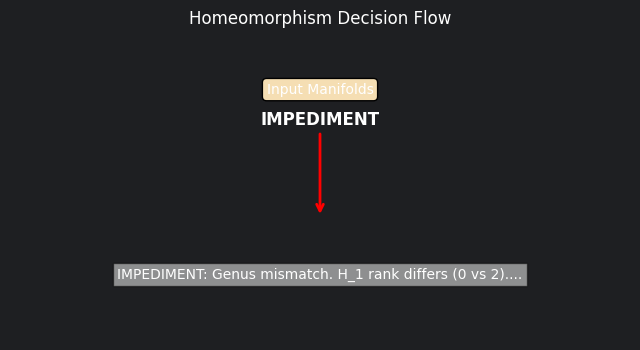

In [7]:
# Visualizing a decision tree branching based on status
def plot_decision_tree(result):
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Root
    ax.text(0.5, 0.8, 'Input Manifolds', ha='center', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # Path to Status
    color = 'green' if result.status == 'success' else 'red'
    ax.annotate(result.status.upper(), xy=(0.5, 0.4), xytext=(0.5, 0.7),
                arrowprops=dict(arrowstyle='->', lw=2, color=color),
                ha='center', fontsize=12, fontweight='bold')
    
    # Reasoning box
    ax.text(0.5, 0.2, result.reasoning[:100] + '...', ha='center', wrap=True,
            bbox=dict(boxstyle='square', facecolor='white', alpha=0.5))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title('Homeomorphism Decision Flow')
    plt.show()

plot_decision_tree(res)

## Failure Modes

1. **Inconclusive Verdicts**: If fundamental group identification fails, the high-dimensional analyzer will return `inconclusive`.
2. **Dimension Confusion**: Invoking `analyze_homeomorphism_2d` on 4-manifolds will lead to incorrect Euler characteristic reasoning.
3. **Missing Certificates**: If the `exact` flag is False, the verdict may not be mathematically rigorous.


In [8]:
# Intentionally triggering an inconclusive result by lack of dimension
try:
    res_fail = analyze_homeomorphism_high_dim_result(sphere, torus, dim=1)
except Exception as e:
    print(f'Caught: {e}')

Caught: Function called on 1D. The s-Cobordism theorem and Wall's high-dimensional surgery framework strictly apply to n >= 5, where the 'Whitney Trick' guarantees enough room to untangle handles.


## Summary Checklist
- [x] Invoked dimension-specific homeomorphism analyzers.
- [x] Parsed `HomeomorphismResult` objects for status and reasoning.
- [x] Identified missing data required for definitive verdicts.
- [x] Linked verdicts to topological theorems via `theorem_tag`.
- [x] Visualized the decision flow for a classification task.

## Exercises
1. **Genus 2**: Build a genus-2 surface and compare it to the Torus. Does the 2D API correctly identify the difference?
2. **Signature Obstruction**: Create two 4D intersection forms with different signatures and verify that the 4D API returns an `impediment`.
3. **Homotopy vs Homeo**: Find two manifolds that are homotopy equivalent but not homeomorphic, and see how the API handles the distinction.
4. **Certificate Inspection**: Extract the `certificates` dictionary from a successful result and explain one of the objects found inside.
5. **3D Geometrization**: Research which geometric structures are currently supported by the 3D heuristic API.

## Key Takeaways
- The **Decision API** is the primary entry point for high-level classification.
- Verdicts are **structured objects**, providing more than just a Boolean answer.
- **Dimension matters**: The mathematical machinery changes completely depending on $n$.
- **Missing Data** is a first-class citizen, allowing for progressive refinement of proofs.

**Ready for [15 - Certificate Workflows from Intermediate Evidence](./15_certificate_workflows_from_intermediate_evidence.ipynb)**
